<a href="https://colab.research.google.com/github/Arya-code2005/Machine_Learning/blob/random_forest/random_forest1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [2]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [3]:

df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()


(100, 6)


,col1,col2,col3,col4,col5,target
0,1.452385,-0.033442,0.615717,0.665599,1.672977,0
1,0.930891,0.675398,0.885978,-0.715744,1.145997,0
2,0.465416,2.633623,1.700287,-2.863932,0.369113,0
3,4.268633,-0.727934,1.105561,-2.994588,1.869862,0
4,0.960263,-0.504195,0.887817,-0.110499,1.887456,0


In [4]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)


In [5]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [6]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [16]:
df1 = combined_sampling(df,0.5,0.5)

In [15]:
import random
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols].copy() # Explicitly create a copy
  new_df['target'] = df['target']
  return new_df

In [17]:
df2 = combined_sampling(df,0.5,0.5)

In [18]:
df3 = combined_sampling(df,0.5,0.5)

In [19]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col5', 'col3', 'target'], dtype='object')
Index(['col5', 'col2', 'target'], dtype='object')
Index(['col1', 'col4', 'target'], dtype='object')


In [20]:
df3

,col1,col4,target
56,0.078292,-1.317487,1
55,2.587195,-0.717016,1
64,0.173960,-0.724749,1
30,0.220997,-1.069559,1
29,-0.166641,-3.017958,1
7,0.788917,-1.577150,1
39,0.662692,-0.984074,1
11,2.041507,-0.162315,0
30,0.220997,-1.069559,1
77,0.472979,-0.298973,1


In [27]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()



In [29]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

In [30]:
from sklearn.tree import plot_tree

[Text(0.2857142857142857, 0.9, 'x[0] <= -0.232\ngini = 0.499\nsamples = 50\nvalue = [24, 26]'),
 Text(0.14285714285714285, 0.7, 'gini = 0.0\nsamples = 22\nvalue = [0, 22]'),
 Text(0.21428571428571427, 0.8, 'True  '),
 Text(0.42857142857142855, 0.7, 'x[1] <= -1.238\ngini = 0.245\nsamples = 28\nvalue = [24, 4]'),
 Text(0.3571428571428571, 0.8, '  False'),
 Text(0.2857142857142857, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.5714285714285714, 0.5, 'x[1] <= 0.901\ngini = 0.077\nsamples = 25\nvalue = [24, 1]'),
 Text(0.42857142857142855, 0.3, 'gini = 0.0\nsamples = 14\nvalue = [14, 0]'),
 Text(0.7142857142857143, 0.3, 'x[1] <= 0.99\ngini = 0.165\nsamples = 11\nvalue = [10, 1]'),
 Text(0.5714285714285714, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8571428571428571, 0.1, 'gini = 0.0\nsamples = 10\nvalue = [10, 0]')]

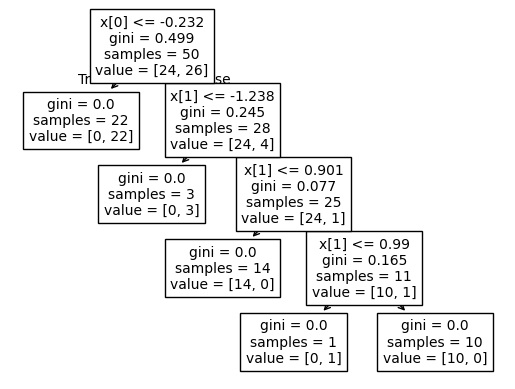

In [31]:
plot_tree(clf1)

In [23]:
plot_tree(clf2)

NameError: name 'plot_tree' is not defined

[Text(0.4583333333333333, 0.9444444444444444, 'x[0] <= 0.238\ngini = 0.487\nsamples = 50\nvalue = [21.0, 29.0]'),
 Text(0.375, 0.8333333333333334, 'gini = 0.0\nsamples = 11\nvalue = [0, 11]'),
 Text(0.41666666666666663, 0.8888888888888888, 'True  '),
 Text(0.5416666666666666, 0.8333333333333334, 'x[0] <= 2.363\ngini = 0.497\nsamples = 39\nvalue = [21, 18]'),
 Text(0.5, 0.8888888888888888, '  False'),
 Text(0.25, 0.7222222222222222, 'x[1] <= -3.026\ngini = 0.436\nsamples = 28\nvalue = [19, 9]'),
 Text(0.16666666666666666, 0.6111111111111112, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.3333333333333333, 0.6111111111111112, 'x[0] <= 0.86\ngini = 0.393\nsamples = 26\nvalue = [19, 7]'),
 Text(0.16666666666666666, 0.5, 'x[0] <= 0.469\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.08333333333333333, 0.3888888888888889, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.25, 0.3888888888888889, 'x[1] <= -0.988\ngini = 0.408\nsamples = 7\nvalue = [2, 5]'),
 Text(0.1666666666666666

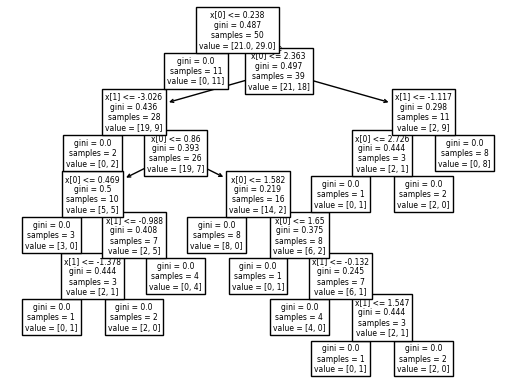

In [32]:
plot_tree(clf3)

In [33]:
clf1.predict(np.array([-1.042498, -0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [34]:
clf2.predict(np.array([-1.042498, -0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [35]:
clf3.predict(np.array([-1.042498, -0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [36]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
51,3.398494,2.410342,0.888420,-0.728457,-2.477178,1
35,1.894229,1.664024,0.577691,-0.579250,0.018802,0
87,1.520756,0.063379,-0.974730,0.336835,-0.659842,0
7,0.788917,-0.130594,-2.038011,-1.577150,-2.343934,1
99,3.398310,0.683014,0.322066,0.520195,0.008253,1
38,2.211855,-0.744846,2.030855,-3.371339,2.750586,0
91,0.657252,-2.528846,-2.954393,-4.349531,-1.972429,1
85,1.954392,0.648448,0.356031,0.796801,0.682295,0
44,1.385285,0.737428,1.601397,-1.762023,1.807373,0
76,1.656948,-1.020063,0.554863,-0.880656,1.729603,0
